In [1]:
%load_ext autoreload
%autoreload 2

from canonical import VectorizedCanonicalBasis
from symbolic import Variable, CounterfactualTerm, Event, Query, P

from loguru import logger
import networkx as nx

In [2]:
X = Variable("X", domain=(0, 1))
W = Variable("W", domain=(0, 1))
Y = Variable("Y", domain=(0, 1))

# obs_data = {
#     (0, 0): 0.5,
#     (0, 1): 0.5,
#     (1, 0): 0.5,
#     (1, 1): 0.5,
# }

# observational probabilities
obs_data = {
    (0, 0, 0): 0.1,
    (0, 0, 1): 0.2,
    (0, 1, 0): 0.1,
    (0, 1, 1): 0.05,
    (1, 0, 0): 0.05,
    (1, 0, 1): 0.05,
    (1, 1, 0): 0.05,
    (1, 1, 1): 0.4,
}

# query1 = P(Y == 1, X == 0)
# query2 = P(Y @ {X: 0} == 1)

query = P(Y @ {X: 0, W: 0} == 0)
# query = P(Y @ {X: 1, W: W @ {X: 0}} == 0)

In [3]:
from inference import ConservativePID

obj = ConservativePID(
    variables=[
        Variable("X", domain=(0, 1)),
        Variable("W", domain=(0, 1)),
        Variable("Y", domain=(0, 1)),
    ],
    observational_data=obs_data,
)

obj.infer(query, ["X", "W", "Y"])

2026-01-26 11:05:17.023 | INFO     | inference:infer:43 - Using fixed causal order: ['X', 'W', 'Y']
2026-01-26 11:05:17.024 | INFO     | canonical:__init__:42 - Generated Basis with 128 worlds.


(0.1, 0.8)

In [4]:
VectorizedCanonicalBasis()

TypeError: VectorizedCanonicalBasis.__init__() missing 1 required positional argument: 'variables'

In [ ]:
dag = obj._extract_partial_order(query)

[Y_{X=1, W=W_{X=0}}]


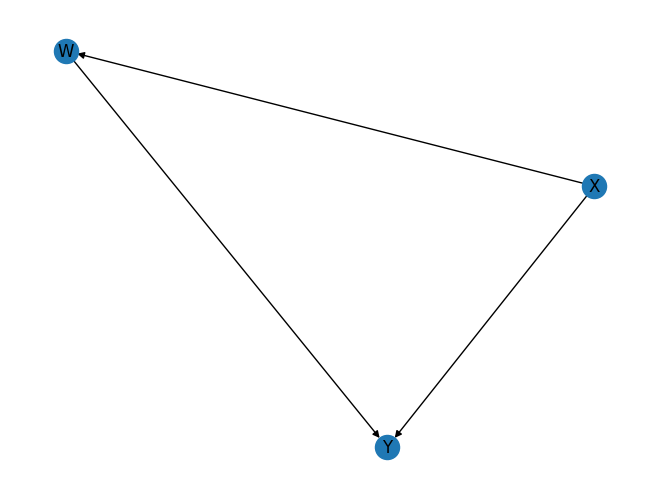

In [ ]:
nx.draw(dag, with_labels=True)

In [30]:
X = Variable("X", domain=(0, 1))
W = Variable("W", domain=(0, 1))
Y = Variable("Y", domain=(0, 1))

nested_term = CounterfactualTerm(Y, {W: W @ {X: 0}})
nested_event = nested_term == 0

<unknown>:56: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:56: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
